# What's special about the top-100 high-volume car washes?

**Question:** why do the ~100 sites that wash **≥150K cars/year** perform so well — what do they have that the rest don't?

**Method.** Describing the winners alone tells you what they *look* like, not what's *special*. So we **contrast** them against the rest of the ~2,000-site panel on every demographic / competitive / traffic feature in the Council sitewise data, then ask a model how much of the volume those features actually explain, and finally split the winners into archetypes.

Sources: `proforma/data/panel/main-data-v2-stitched.csv` (monthly washes) + `experiments/council/data/Council--site-wise-data.csv` (sitewise).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":.25,"axes.spines.top":False,"axes.spines.right":False})
C = dict(hi="#2563eb", rest="#94a3b8", up="#2563eb", dn="#dc2626", a=["#2563eb","#f59e0b","#10b981"])
REPO = "/Users/dhruvsood/sonnysDataCollection"

# ---- annual washes per site: latest COMPLETE (12-mo) year in 2022-2025 (2026/27 are partial/forecast) ----
p = pd.read_csv(f"{REPO}/proforma/data/panel/main-data-v2-stitched.csv", low_memory=False)
p["site_key"] = p.client_id.astype(str)+"_"+p.site_id.astype(str)
p["wash"] = p.mem_wash_count.fillna(0)+p.ret_wash_count.fillna(0)
g = p[p.year.between(2022,2025)].groupby(["site_key","year"]).agg(wash=("wash","sum"),n=("month","nunique")).reset_index()
annual = g[g.n==12].sort_values(["site_key","year"]).groupby("site_key").tail(1).set_index("site_key")["wash"].rename("annual")

# ---- Council sitewise features (coerce to numeric) ----
c = pd.read_csv(f"{REPO}/experiments/council/data/Council--site-wise-data.csv", low_memory=False)
c["site_key"] = c.client_id.astype(str)+"_"+c.site_id.astype(str)
TTL = [f"Nearest StreetLight US Hourly-ttl_{x}" for x in ["overnight","breakfast","lunch","afternoon","dinner","night"]]
FEAT = {"2025 Estimate":"population","Growth 2025-2020":"growth_past5","Growth 2030-2025":"growth_next5",
        "2025 Average Age":"avg_age","Median Household Income":"med_income","2025 % HH with Income $50K+":"pct_hh_50k",
        "Average Number of Vehicles Available":"avg_vehicles","Total Vehicles Available in the Market":"total_vehicles",
        "Renter-Occupied":"renter_occ","Count of Car Wash Competitors":"n_competitors",
        "Nearest Car Wash Competitors-Distance":"nearest_comp_mi","Count of ChainXY VT - Mass Merchant":"n_massmerch",
        "Count of ChainXY VT - Grocery":"n_grocery","Count of ChainXY VT - Department Store":"n_deptstore"}
for k in list(FEAT)+TTL: c[k] = pd.to_numeric(c[k], errors="coerce")
c["traffic_daily"] = c[TTL].sum(axis=1, min_count=1)
cc = c[["site_key"]+list(FEAT)].rename(columns=FEAT).set_index("site_key")
cc["traffic_daily"] = c.set_index("site_key")["traffic_daily"]
cc["competitors_per_10k_pop"] = cc.n_competitors/(cc.population/10000).replace(0, np.nan)

df = cc.join(annual, how="inner").dropna(subset=["annual"])
df["is_high"] = df.annual >= 150_000
print(f"sites with annual + sitewise data: {len(df)}")
print(f"  HIGH performers (>=150k/yr): {df.is_high.sum()}   |   rest: {(~df.is_high).sum()}")
print(f"  HIGH median annual {df[df.is_high].annual.median():,.0f}  vs  rest {df[~df.is_high].annual.median():,.0f}")

sites with annual + sitewise data: 1409
  HIGH performers (>=150k/yr): 251   |   rest: 1158
  HIGH median annual 186,257  vs  rest 75,178


## 1 · What separates the winners? (feature-by-feature)

For every feature, the median among HIGH performers vs the rest, the **ratio**, **Cliff's delta** (effect size: how consistently HIGH > rest, −1..+1), the **Spearman correlation** with annual volume across all sites, and the Mann–Whitney p-value. Sorted by effect size.

In [2]:
def cliffs(a, b):
    a = np.sort(np.asarray(a, float)); b = np.asarray(b, float); n1, n2 = len(a), len(b)
    if n1 == 0 or n2 == 0: return np.nan
    more = np.searchsorted(a, b, "left").sum(); less = (n1 - np.searchsorted(a, b, "right")).sum()
    return (less - more) / (n1 * n2)

FEATS = ["population","total_vehicles","renter_occ","traffic_daily","growth_past5","growth_next5",
         "n_competitors","competitors_per_10k_pop","n_massmerch","n_grocery","n_deptstore",
         "med_income","avg_income" if "avg_income" in df else "pct_hh_50k","pct_hh_50k","avg_vehicles",
         "nearest_comp_mi","avg_age"]
FEATS = [f for i,f in enumerate(FEATS) if f in df.columns and f not in FEATS[:i]]
rows = []
for f in FEATS:
    hi = df.loc[df.is_high, f].dropna(); lo = df.loc[~df.is_high, f].dropna()
    if len(hi) < 10 or len(lo) < 10: continue
    p_ = mannwhitneyu(hi, lo, alternative="two-sided").pvalue
    rho = spearmanr(df[f], df.annual, nan_policy="omit").correlation
    rows.append((f, hi.median(), lo.median(), hi.median()/lo.median() if lo.median() else np.nan, cliffs(hi, lo), rho, p_))
contrast = pd.DataFrame(rows, columns=["feature","median_high","median_rest","ratio","cliffs_delta","spearman_r","mwu_p"])
contrast = contrast.reindex(contrast.cliffs_delta.abs().sort_values(ascending=False).index).reset_index(drop=True)
contrast.style.format({"median_high":"{:,.1f}","median_rest":"{:,.1f}","ratio":"{:.2f}",
                       "cliffs_delta":"{:+.3f}","spearman_r":"{:+.3f}","mwu_p":"{:.1e}"})

,feature,median_high,median_rest,ratio,cliffs_delta,spearman_r,mwu_p
0,population,"60,501.4","43,940.9",1.38,+0.229,+0.058,1.2e-08
1,total_vehicles,"42,657.4","31,450.3",1.36,+0.215,+0.047,8.5e-08
2,renter_occ,"7,744.9","5,721.5",1.35,+0.194,+0.060,1.4e-06
3,traffic_daily,"15,191.0","12,496.0",1.22,+0.159,+0.088,7.9e-05
4,growth_past5,0.0,0.0,1.45,+0.144,+0.109,3.5e-04
5,n_competitors,4.0,3.0,1.33,+0.138,+0.015,5.3e-04
6,n_massmerch,2.0,1.0,2.00,+0.135,+0.056,4.5e-04
7,growth_next5,0.0,0.0,1.59,+0.122,+0.077,2.4e-03
8,n_grocery,3.0,2.0,1.50,+0.120,+0.079,2.5e-03
9,med_income,"82,294.9","78,830.2",1.04,+0.111,-0.024,5.9e-03


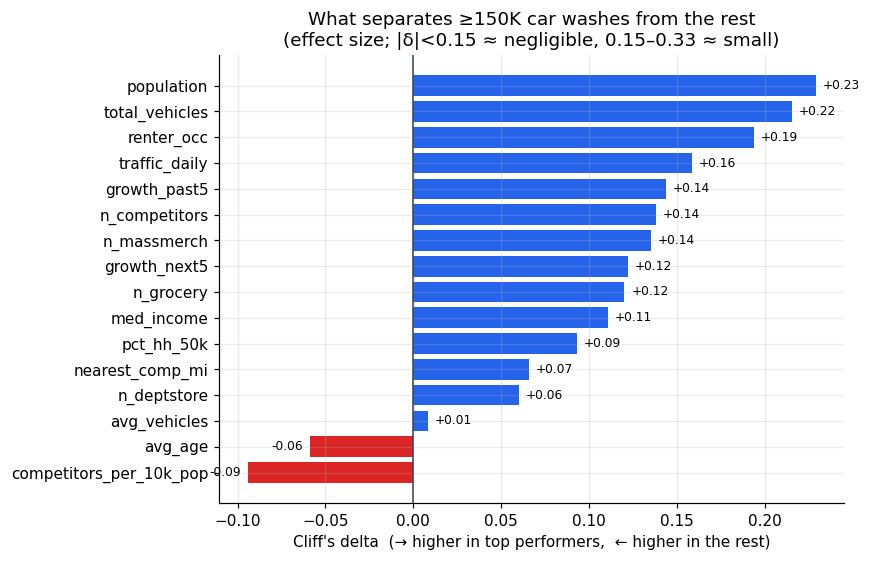

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.2))
d = contrast.sort_values("cliffs_delta")
ax.barh(d.feature, d.cliffs_delta, color=[C["up"] if v>0 else C["dn"] for v in d.cliffs_delta])
ax.axvline(0, color="#334155", lw=1)
ax.set_xlabel("Cliff's delta  (→ higher in top performers,  ← higher in the rest)")
ax.set_title("What separates ≥150K car washes from the rest\n(effect size; |δ|<0.15 ≈ negligible, 0.15–0.33 ≈ small)")
for y, v in enumerate(d.cliffs_delta): ax.text(v+(0.004 if v>=0 else -0.004), y, f"{v:+.2f}", va="center", ha="left" if v>=0 else "right", fontsize=8)
plt.tight_layout(); plt.show()

**Read-out.** The separators, in order, are all **demand / density** signals — population, total vehicles, renters, daily traffic, market **growth**, and retail gravity (mass-merchant + grocery anchors). Two things you'd *expect* to matter barely move the needle:
- **Income is essentially flat** (ratio ≈ 1.03–1.04, Spearman ≈ 0) — winners are **not** in richer areas.
- **Vehicles-per-household** is identical (δ ≈ 0.01).

And note the sign on competition below — it points the "wrong" way.

## 2 · Distributions of the top separators (HIGH vs rest)

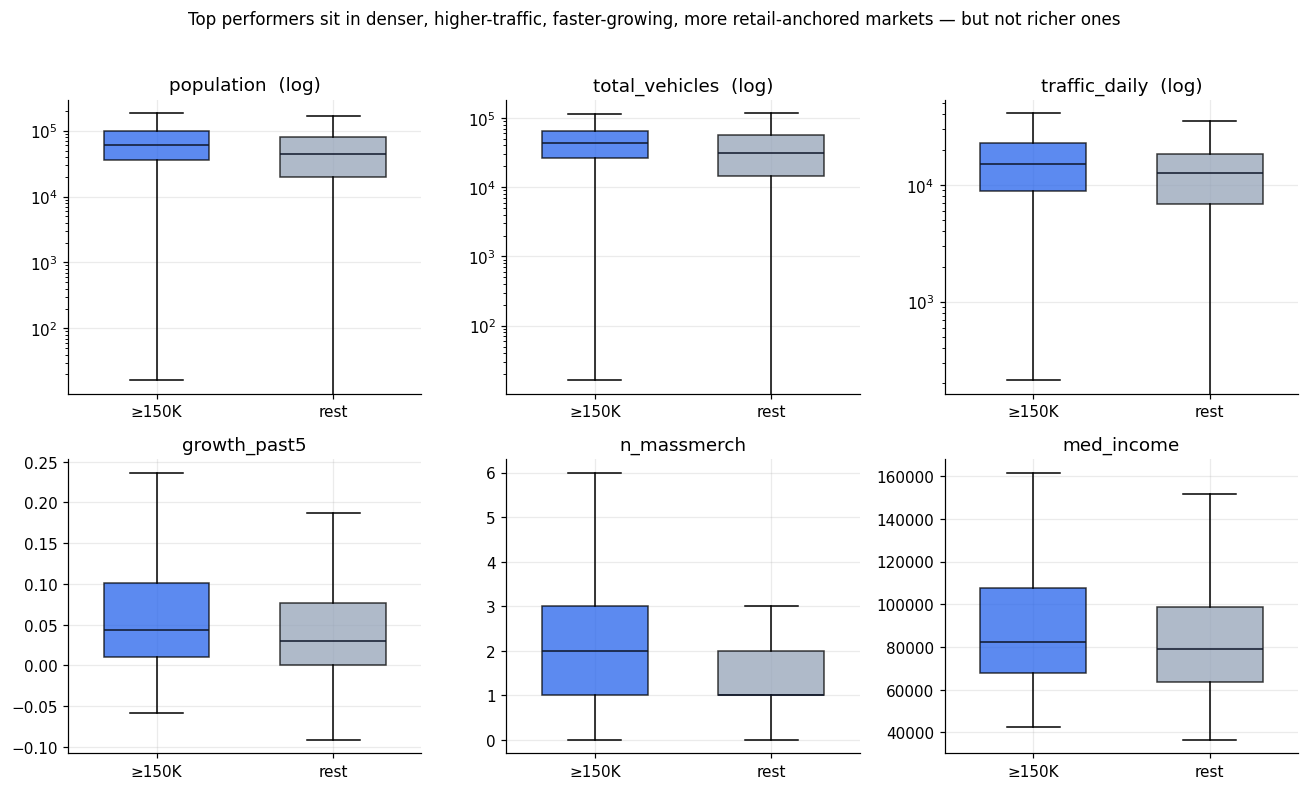

In [4]:
show = ["population","total_vehicles","traffic_daily","growth_past5","n_massmerch","med_income"]
logs = {"population","total_vehicles","traffic_daily"}
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, f in zip(axes.ravel(), show):
    data = [df.loc[df.is_high, f].dropna(), df.loc[~df.is_high, f].dropna()]
    bp = ax.boxplot(data, labels=["≥150K","rest"], showfliers=False, patch_artist=True, widths=.6)
    for patch, col in zip(bp["boxes"], [C["hi"], C["rest"]]): patch.set_facecolor(col); patch.set_alpha(.75)
    for med in bp["medians"]: med.set_color("#0f172a")
    if f in logs: ax.set_yscale("log")
    ax.set_title(f + ("  (log)" if f in logs else ""))
fig.suptitle("Top performers sit in denser, higher-traffic, faster-growing, more retail-anchored markets — but not richer ones", y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

Population, vehicles, traffic, growth and mass-merchant count all shift up for the ≥150K group; **median income** (bottom-right) overlaps almost completely — the affluence you'd assume drives a car wash is a non-factor here.

## 3 · The two counterintuitive findings: income & competition

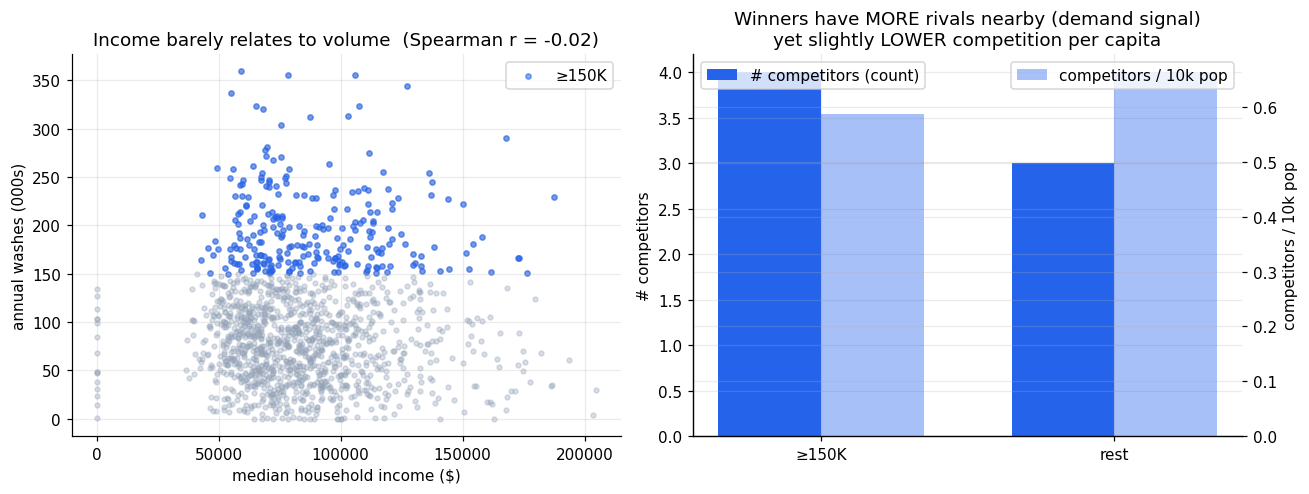

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
# (a) annual vs income — no relationship
ax[0].scatter(df.med_income, df.annual/1000, s=10, alpha=.35, color=C["rest"])
ax[0].scatter(df.loc[df.is_high,"med_income"], df.loc[df.is_high,"annual"]/1000, s=12, alpha=.55, color=C["hi"], label="≥150K")
rho = spearmanr(df.med_income, df.annual, nan_policy="omit").correlation
ax[0].set(xlabel="median household income ($)", ylabel="annual washes (000s)",
          title=f"Income barely relates to volume  (Spearman r = {rho:+.02f})"); ax[0].legend()
# (b) competition: winners face MORE rivals but slightly LOWER saturation-per-capita
comp = pd.DataFrame({"n_competitors":[df.loc[df.is_high,"n_competitors"].median(), df.loc[~df.is_high,"n_competitors"].median()],
                     "competitors_per_10k_pop":[df.loc[df.is_high,"competitors_per_10k_pop"].median(), df.loc[~df.is_high,"competitors_per_10k_pop"].median()]}, index=["≥150K","rest"])
x = np.arange(2); w=.35
ax[1].bar(x-w/2, comp.n_competitors, w, color=C["hi"], label="# competitors (count)")
ax2 = ax[1].twinx(); ax2.bar(x+w/2, comp.competitors_per_10k_pop, w, color=C["up"], alpha=.4, label="competitors / 10k pop")
ax[1].set_xticks(x); ax[1].set_xticklabels(comp.index); ax[1].set_ylabel("# competitors"); ax2.set_ylabel("competitors / 10k pop")
ax[1].set_title("Winners have MORE rivals nearby (demand signal)\nyet slightly LOWER competition per capita")
ax[1].legend(loc="upper left"); ax2.legend(loc="upper right")
plt.tight_layout(); plt.show()

- **Income ≈ irrelevant** to volume (r ≈ 0). A car wash's throughput isn't gated by how rich the neighbourhood is.
- **More competitors, not fewer.** Top sites have *more* express rivals nearby (median 4 vs 3) — because a crowded car-wash field is a **market that supports washing**, i.e. a demand signal. But normalised per capita they're in *slightly less* saturated markets: big demand, room for all. "Go where the washes already are" beats "find the empty market."  

## 4 · Can location actually *predict* who wins? (mostly no)

If demographics/competition/traffic explained performance, a model should predict annual volume from them. Let's check (5-fold CV).

Predict ANNUAL washes from sitewise features:  CV R^2 = -0.064 ± 0.086   (0 = no better than the mean)
Classify HIGH (>=150k) vs rest:                CV AUC = 0.603 ± 0.045   (0.5 = coin flip)


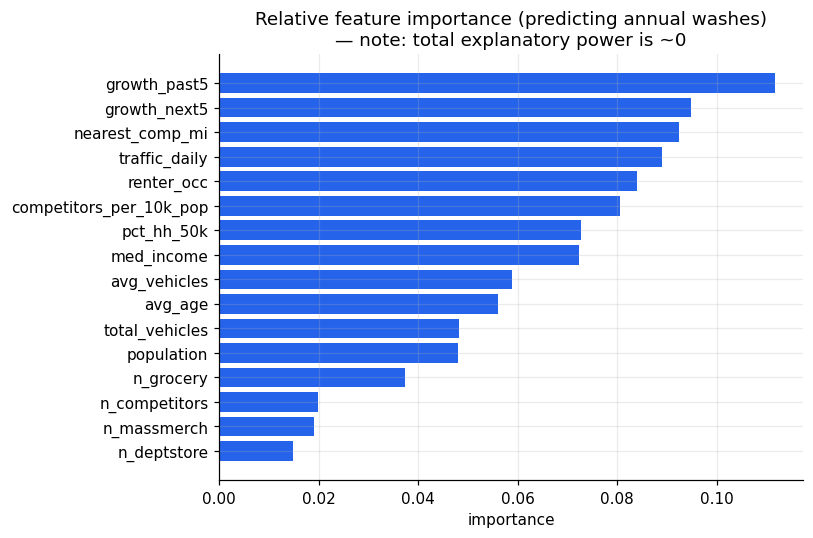

In [6]:
X = df[[c for c in df.columns if c not in ("annual","is_high")]].copy()
X = X.fillna(X.median()); y = df.annual
r2 = cross_val_score(RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=15, random_state=0), X, y, cv=5, scoring="r2")
auc = cross_val_score(RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=15, random_state=0), X, df.is_high.astype(int), cv=5, scoring="roc_auc")
print(f"Predict ANNUAL washes from sitewise features:  CV R^2 = {r2.mean():+.3f} ± {r2.std():.3f}   (0 = no better than the mean)")
print(f"Classify HIGH (>=150k) vs rest:                CV AUC = {auc.mean():.3f} ± {auc.std():.3f}   (0.5 = coin flip)")
rf = RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=15, random_state=0).fit(X, y)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(imp.index, imp.values, color=C["hi"]); ax.set_title("Relative feature importance (predicting annual washes)\n— note: total explanatory power is ~0"); ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

**This is the headline.** Cross-validated **R² ≈ 0** (negative = worse than guessing the average) and classifier **AUC ≈ 0.60** (barely above a coin flip). The sitewise demographics, competition and traffic **do not explain how many cars a site washes.** The importance ranking above is just *relative* — the whole set explains almost nothing.

So what *does* make a top performer? Whatever isn't in this data: **tunnel throughput / equipment, the membership program, pricing, operator quality and local marketing, and being an entrenched early mover.** This matches the repo's prior findings — demographics/competition are weak predictors while capacity/operations dominate (`docs`/site-scoring notes: *"only capacity factors predict actual perf; proformas over-project"*).

## 5 · So what IS it? Not the market — the *capture rate*, powered by membership

If location can't predict volume, the answer has to be in how much of the local market a site **captures**. Volume = market size x capture rate. Let's see which half actually moves — and check the sites' *own* operating data (membership), which the demographics never saw.

In [7]:
# decompose volume into market size x capture rate, + the membership engine (from the panel's own data)
from scipy.stats import spearmanr as sr
mem = p.groupby('site_key').agg(mem=('mem_wash_count','sum'), ret=('ret_wash_count','sum'),
                                mem_pur=('mem_purchase_count','sum'), asp_mem=('ASP_mem','median'))
mem['mem_share'] = mem.mem/(mem.mem+mem.ret)
E = df[['annual','population','is_high']].join(mem)
E = E[(E.annual>0) & (E.population>0)]
E['capture'] = E.annual/E.population                 # washes per resident per year
print('Spearman correlation with annual washes:')
print('  population        %+.3f   (market size)'  % sr(E.annual, E.population).correlation)
print('  washes / capita   %+.3f   (CAPTURE rate)' % sr(E.annual, E.capture).correlation)
print('  membership share  %+.3f   (the engine)'   % sr(E.annual, E.mem_share, nan_policy='omit').correlation)
la, lp, lc = np.log(E.annual), np.log(E.population), np.log(E.capture)
share_cap = (lc.var() + np.cov(lp, lc)[0,1]) / la.var()
print('\nVariance of log(volume): %.0f%% comes from CAPTURE rate, %.0f%% from population size.' % (share_cap*100, 100-share_cap*100))

Spearman correlation with annual washes:
  population        +0.053   (market size)
  washes / capita   +0.548   (CAPTURE rate)
  membership share  +0.597   (the engine)

Variance of log(volume): 100% comes from CAPTURE rate, 0% from population size.


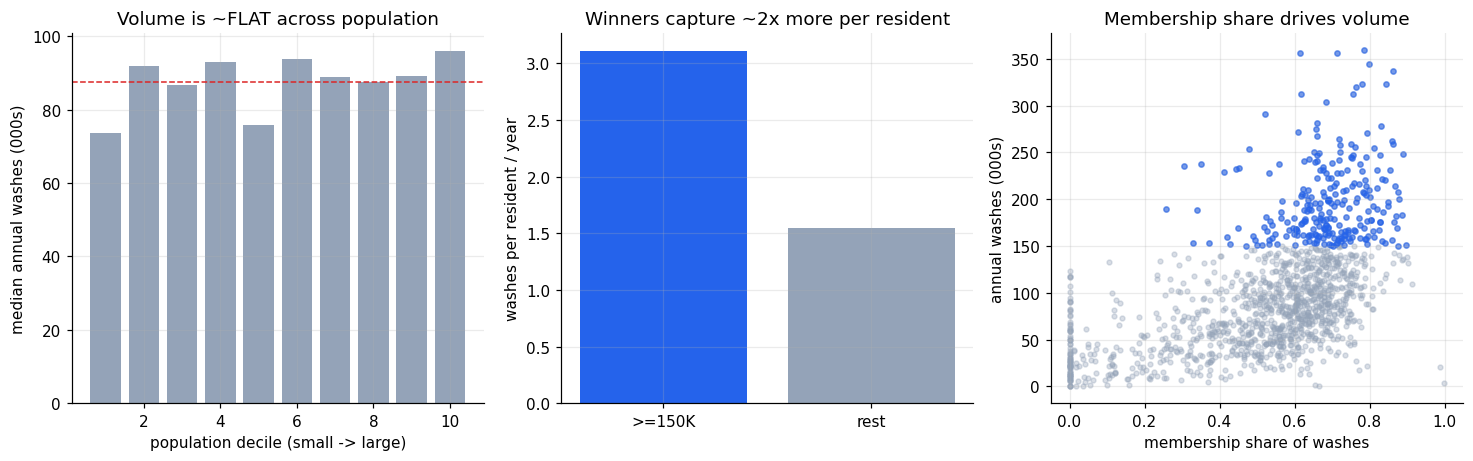

high vs rest (median):
  population   high     60,501   rest     44,901   ratio 1.35
  capture      high       3.11   rest       1.55   ratio 2.01
  mem_share    high      69.1%   rest      56.1%   ratio 1.23
  mem_pur      high    133,217   rest     38,512   ratio 3.46
  asp_mem      high     $55.56   rest     $49.92   ratio 1.11


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.3))
# (a) population deciles -> volume is ~flat
E2 = df[df.annual>0].copy(); E2['pop_decile'] = pd.qcut(E2.population, 10, labels=False)+1
dec = E2.groupby('pop_decile').annual.median()
ax[0].bar(dec.index, dec.values/1000, color=C['rest']); ax[0].axhline(dec.mean()/1000, color=C['dn'], ls='--', lw=1)
ax[0].set(xlabel='population decile (small -> large)', ylabel='median annual washes (000s)', title='Volume is ~FLAT across population')
# (b) capture rate: winners ~2x
ch, cl = E.loc[E.is_high,'capture'].median(), E.loc[~E.is_high,'capture'].median()
ax[1].bar(['>=150K','rest'], [ch, cl], color=[C['hi'], C['rest']])
ax[1].set(ylabel='washes per resident / year', title='Winners capture ~2x more per resident')
# (c) membership share vs volume
ax[2].scatter(E.mem_share, E.annual/1000, s=10, alpha=.35, color=C['rest'])
ax[2].scatter(E.loc[E.is_high,'mem_share'], E.loc[E.is_high,'annual']/1000, s=12, alpha=.55, color=C['hi'])
ax[2].set(xlabel='membership share of washes', ylabel='annual washes (000s)', title='Membership share drives volume')
plt.tight_layout(); plt.show()
print('high vs rest (median):')
for col, fmt in [('population','{:,.0f}'),('capture','{:.2f}'),('mem_share','{:.1%}'),('mem_pur','{:,.0f}'),('asp_mem','${:.2f}')]:
    print('  %-12s high %10s   rest %10s   ratio %.2f' % (col, fmt.format(E.loc[E.is_high,col].median()),
          fmt.format(E.loc[~E.is_high,col].median()), E.loc[E.is_high,col].median()/E.loc[~E.is_high,col].median()))

**Here's the answer — and it's *not* population.**
- Population correlates with volume at **r ≈ 0.05** (~zero), volume is essentially **flat across population deciles** (a ~9K-person town site does about as much as a ~160K metro one), and in a variance decomposition **~100% of the differences in volume come from capture rate, ~0% from population**. Market size and capture even trade off (bigger market → lower per-capita capture).
- **Winners capture ~2x more washes per resident** (3.1 vs 1.5 /person/yr).
- **The engine of that capture is MEMBERSHIP.** High performers run **69% membership share vs 56%**, have sold **~3.5x more memberships** (133K vs 38K), and price membership **~11% higher**. Unlimited members wash 2–3x/month — a recurring, high-frequency base retail traffic can't match.

So the "something special" is a **membership flywheel** (fed by throughput/brand/marketing) — a *commercial capability the operator builds*, not an endowment of the location.

## 6 · Three routes to winning — archetypes of the top 100

Even though no single profile defines a winner, the top 100 fall into a few recognisable **shapes** (KMeans, k=3, on population / income / traffic / competitors / mass-merchants / growth).

,n,annual,population,med_income,traffic,competitors,mass_merch,growth
0: Affluent growing suburb,30,"197,332","55,874","$108,253","14,912",3.000000,1.000000,7.1%
1: Dense metro corridor,23,"214,058","117,466","$105,994","25,335",7.000000,3.000000,1.7%
2: Small modest-income town,47,"201,824","35,727","$68,140","10,944",3.000000,1.000000,3.5%


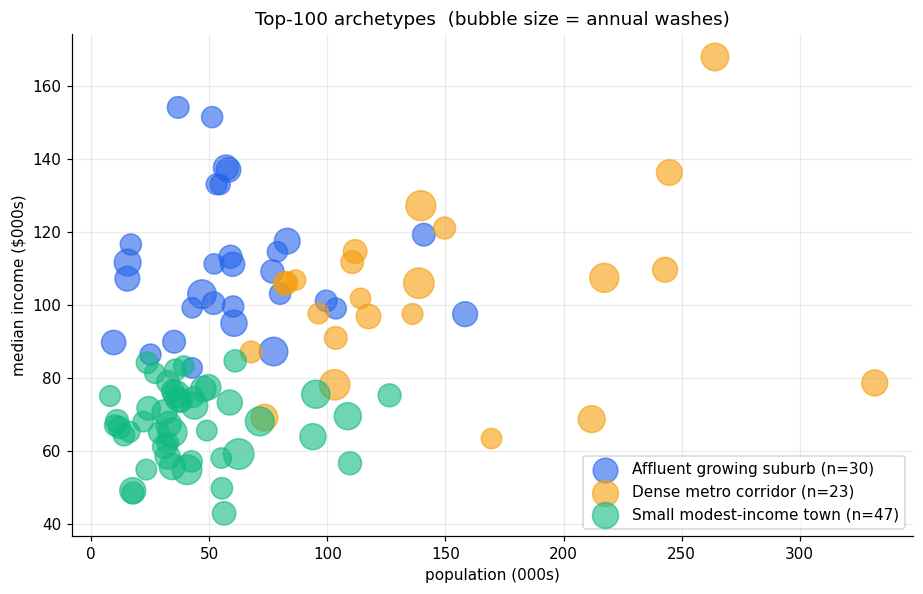

In [9]:
sel = pd.read_csv("/private/tmp/claude-501/-Users-dhruvsood-sonnysDataCollection/58e526ff-6d86-4cf8-a140-18221a9877bc/scratchpad/_sel100.csv")
sel["site_key"] = sel.client_id.astype(str)+"_"+sel.site_id.astype(str)
T = df.loc[df.index.isin(set(sel.site_key))].copy()
V = ["population","med_income","traffic_daily","n_competitors","n_massmerch","growth_past5"]
T["arch"] = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(T[V].fillna(T[V].median())))
prof = T.groupby("arch").agg(n=("annual","size"), annual=("annual","median"), population=("population","median"),
        med_income=("med_income","median"), traffic=("traffic_daily","median"),
        competitors=("n_competitors","median"), mass_merch=("n_massmerch","median"), growth=("growth_past5","median"))
LABEL = {}
for a,row in prof.iterrows():
    if row.population>=90_000: LABEL[a]="Dense metro corridor"
    elif row.med_income>=95_000: LABEL[a]="Affluent growing suburb"
    else: LABEL[a]="Small modest-income town"
prof.index = [f"{a}: {LABEL[a]}" for a in prof.index]
display(prof.style.format({"annual":"{:,.0f}","population":"{:,.0f}","med_income":"${:,.0f}","traffic":"{:,.0f}","growth":"{:.1%}"}))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for a in sorted(T.arch.unique()):
    s = T[T.arch==a]
    ax.scatter(s.population/1000, s.med_income/1000, s=s.annual/900, alpha=.6, color=C["a"][a], label=f"{LABEL[a]} (n={len(s)})")
ax.set(xlabel="population (000s)", ylabel="median income ($000s)", title="Top-100 archetypes  (bubble size = annual washes)")
ax.legend(); plt.tight_layout(); plt.show()

Three genuinely different ways to be a top-100 car wash:
1. **Small modest-income town** (the *largest* group) — modest population (~35K) and income (~$68K), thin competition; the site simply **owns a small market**.
2. **Affluent growing suburb** — mid-size, higher income, fastest growth; classic suburban winner.
3. **Dense metro corridor** — big population, high traffic, many competitors + retail anchors; wins on **sheer volume of cars** despite the crowding.

The takeaway from the mix: you do **not** need a rich, dense metro. Nearly half of the top performers are in smaller, ordinary-income towns.

## Summary — what's actually special about the top 100

1. **It is NOT population or location.** Population barely correlates with volume (r ≈ 0.05), volume is flat across population deciles, and location features as a whole can't predict volume (CV **R² ≈ 0**, classifier **AUC ≈ 0.60**). ~100% of the difference in volume traces to capture rate, ~0% to market size.
2. **It IS capture rate** — winners wash **~2x more cars per resident** (3.1 vs 1.5 /person/yr). They extract far more from a market of the same size.
3. **The engine of capture is MEMBERSHIP.** Top sites run **69% vs 56% membership share**, sold **~3.5x more memberships**, and price membership **~11% higher**. Unlimited members = recurring, high-frequency washers = the flywheel.
4. **What *weakly* separates the winners' locations** is demand-density (population, vehicles, renters, traffic, growth, retail anchors) — **not wealth** (income r ≈ 0). And **competition is a green light**: winners have *more* rivals nearby (demand signal), slightly *less* saturation per capita.
5. **Winning still comes in three shapes** — small-town market-owner (the largest group), affluent-suburb, and dense-metro-corridor — so there's no single "ideal" location profile to screen for.

*Practical implication:* the location screen (demand density + growth + retail gravity + a market already busy with washes, **not** wealth or empty markets) only gets you a viable site. **The volume is won on the membership flywheel and operations** — that's the capability that turns a viable site into a 200K/yr one.